# Forecasting con TimeXer — Intensidad de tráfico M30 (Rolling Evaluation)

Este notebook implementa el modelo **TimeXer** (pytorch-forecasting) para predecir la intensidad de tráfico
en los sensores de la M30 de Madrid, utilizando variables exógenas.

TimeXer es un modelo transformer que tokeniza la serie endógena en *patches* y las variables exógenas
a nivel de *variate*, conectándolas mediante un mecanismo de atención dual con un *global token*.

**Target**: `intensidad` (vehículos/hora por sensor)
**Horizonte de predicción**: 96 horas (4 días)
**Contexto**: 1440 horas
**Evaluación**: rolling window sobre el último ~14.5% de cada sensor (idéntico a Chronos-2)
**Modelo**: `TimeXer` — transformer supervisado con soporte nativo de covariables exógenas.

In [1]:
%pip install pytorch-forecasting pandas numpy seaborn matplotlib

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer
from pytorch_forecasting.models.timexer import TimeXer
from pytorch_forecasting.metrics import QuantileLoss, MAE, RMSE, SMAPE, MAPE

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

PREDICTION_LENGTH = 96
CONTEXT_LENGTH = 1440   # 60 days
PATCH_LENGTH = 24      # 1 day per patch → 7 patches
ROLLING_STEP = 24      # rolling window step in hours
TEST_MONTHS = 2        # last 2 months of each sensor reserved for testing (~1512h)
VAL_LENGTH = 24 * 28   # 28 days of multi-origin validation (aligned with Chronos-2)
BATCH_SIZE = 512
MAX_EPOCHS = 20
SEED = 42

pl.seed_everything(SEED)
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 10.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


Seed set to 42


PyTorch: 2.10.0+cu128
Device: cuda


## 1. Carga y preparación del dataset

Se carga el dataset combinado tráfico-meteo y se crea el `time_idx` entero requerido por pytorch-forecasting.

In [2]:
TARGET = 'intensidad'
ID_COL = 'id'
TS_COL = 'fecha'

FORECAST_WEATHER_COLS = ['forecast_temp', 'forecast_prec']

# Variables observadas solo en pasado/historia (ALL_FORE: no observed weather)
PAST_ONLY_COVARIATES = ['ocupacion', 'vmed']

# Variables conocidas a futuro
TIME_VARYING_KNOWN_REALS = FORECAST_WEATHER_COLS + ['angle_sin', 'angle_cos']
TIME_VARYING_KNOWN_CATS = ['dia_semana', 'hora_dia', 'mes', 'festivo', 'vispera_festivo', 'distrito']

# --- target lags for hourly traffic ---
LAGS = [1, 24, 48, 96]
MAX_LAG = max(LAGS)

# --- Load ---
df_raw = pd.read_csv('/kaggle/input/datasets/jose1980/traffic-meteo-14-slice/traffic-meteo-14-slice.csv', parse_dates=[TS_COL])
#df_raw = pd.read_csv('dataset/processed/traffic-meteo-14-slice.csv', parse_dates=[TS_COL])

print(f'Dataset shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'Sensors: {df_raw[ID_COL].nunique()}')
print(f'Date range: {df_raw[TS_COL].min()} — {df_raw[TS_COL].max()}')

# --- Select & prepare columns ---
keep_cols = [
                TS_COL, ID_COL, TARGET,
                'ocupacion', 'vmed',
                'forecast_temp', 'forecast_prec',
                'angle_sin', 'angle_cos',
            ] + TIME_VARYING_KNOWN_CATS
keep_cols = list(dict.fromkeys(keep_cols))

df = df_raw[keep_cols + ['peso_loss']].copy()

# Only nominal categoricals to string — ordinal/cyclical vars stay numeric
for col in TIME_VARYING_KNOWN_CATS:
    df[col] = df[col].astype(str)
df[ID_COL] = df[ID_COL].astype(str)

# Sort and create integer time index per sensor
df = df.sort_values([ID_COL, TS_COL]).reset_index(drop=True)
df['time_idx'] = df.groupby(ID_COL).cumcount()

del df_raw  # free memory

print(f'\ntime_idx range: 0 — {df["time_idx"].max()}')
print('Hours per sensor (should be equal):')
print(df.groupby(ID_COL)['time_idx'].max().describe()[['min', 'max', 'mean']])
print(f'LAGS={LAGS} | MAX_LAG={MAX_LAG}')
print(f'Forecast weather (known future): {FORECAST_WEATHER_COLS}')
df.head(3)

Dataset shape: 3,597,048 rows, 35 columns
Sensors: 351
Date range: 2024-12-29 00:00:00 — 2026-02-28 23:00:00

time_idx range: 0 — 10247
Hours per sensor (should be equal):
min     10247.0
max     10247.0
mean    10247.0
Name: time_idx, dtype: float64
LAGS=[1, 24, 48, 96] | MAX_LAG=96
Forecast weather (known future): ['forecast_temp', 'forecast_prec']


,fecha,id,intensidad,ocupacion,vmed,forecast_temp,forecast_prec,angle_sin,angle_cos,dia_semana,hora_dia,mes,festivo,vispera_festivo,distrito,peso_loss,time_idx
0,2024-12-29 00:00:00,1006,627.0,2.00,66.5,2.5,0.0,-0.128502,-0.991709,6,0,12,0,0,10.0,1.0,0
1,2024-12-29 01:00:00,1006,570.0,1.75,68.0,1.9,0.0,-0.128502,-0.991709,6,1,12,0,0,10.0,1.0,1
2,2024-12-29 02:00:00,1006,411.0,1.50,66.5,1.7,0.0,-0.128502,-0.991709,6,2,12,0,0,10.0,1.0,2


## 2. Clasificación de variables para TimeXer

TimeXer distingue entre variables exógenas conocidas a futuro, variables observadas solo en el pasado
y la serie endógena objetivo. La tabla resume la asignación usada en este notebook:

| Categoría                          | Variables                                                         |
|------------------------------------|-------------------------------------------------------------------|
| **Known reals** (futuro conocido)  | `forecast_temp`, `forecast_prec`, `angle_sin`, `angle_cos`       |
| **Known categoricals** (futuro)    | `dia_semana`, `hora_dia`, `mes`, `festivo`, `vispera_festivo`, `distrito` |
| **Unknown reals** (solo pasado)    | `intensidad` (target), `ocupacion`, `vmed`                       |
| **Static categorical**             | `id` (identificador del sensor)                                   |
| **Lags del target**                | 1h, 24h, 48h, 96h — añadidos como variables de encoder           |

### Variables conocidas a futuro — Reales
`forecast_temp` y `forecast_prec` son predicciones meteorológicas disponibles hasta el horizonte.
`angle_sin` y `angle_cos` codifican de forma cíclica el ángulo solar del día del año.

### Variables conocidas a futuro — Categóricas
`dia_semana`, `hora_dia`, `mes`, `festivo`, `vispera_festivo` y `distrito` son variables calendáricas
y de localización. Se tratan como nominales (string) para que el modelo aprenda embeddings independientes:
sus valores numéricos son etiquetas arbitrarias sin distancia semántica.

### Variables observadas solo en el pasado
`ocupacion` y `vmed` son observaciones del propio sensor, desconocidas en el horizonte.
`forecast_temp` y `forecast_prec` se usan como covariables conocidas tanto en el encoder (historia)
como en el decoder (horizonte) — variante **ALL_FORE**: sin clima observado (`temp`/`prcp`).

### Diferencia con Chronos-2
Chronos-2 infiere automáticamente qué columnas son past-only vs. future comparando `df` y `future_df`.
TimeXer requiere declaración explícita en el `TimeSeriesDataSet`.
En esta variante ALL_FORE se usa `TimeXer` estándar (sin enmascaramiento de clima observado).

## 3. Train / Validation / Test split y ventanas de evaluación rolling

Se reserva el último **`TEST_MONTHS`** meses de cada sensor como conjunto de test (fijo en horas
independientemente del tamaño del dataset).
Dentro del test split se aplica **evaluación rolling**:

1. Cada ventana predice `PREDICTION_LENGTH` (96h) usando `CONTEXT_LENGTH` (1440h) de historia.
2. Dado que el modelo usa lags de hasta `MAX_LAG=96h`, cada ventana necesita en total
   `CONTEXT_LENGTH + MAX_LAG = 1536h` de histórico antes del inicio de la predicción.
3. Las ventanas avanzan en pasos de `ROLLING_STEP` (24h).
4. Las métricas se calculan por ventana y se agregan (media ± std).

Para el entrenamiento, se usa todo lo anterior a la cola de validación. La validación se construye
con **múltiples orígenes de predicción** dentro de una cola de `VAL_LENGTH` (28 días) justo antes
del test split. Esto da ~25 orígenes por sensor en lugar de solo 1, proporcionando una
señal de early stopping mucho más robusta.

| Conjunto    | Rango                                          | Propósito                      |
|-------------|------------------------------------------------|--------------------------------|
| Train       | `[0, test_start - VAL_LENGTH)`                 | Entrenamiento supervisado       |
| Validation  | `[0, test_start)` con ~25 orígenes rolling      | Early stopping (multi-origen)   |
| Test        | `[N - test_size, N)` — 59 rolling windows      | Evaluación final (= Chronos-2) |


In [3]:
max_time_idx = df['time_idx'].max()
n_per_sensor = max_time_idx + 1   # all sensors have equal length

# Test split: last TEST_MONTHS months of each sensor (fixed hours regardless of dataset size)
example_sid = df[ID_COL].iloc[0]
example_sensor = df[df[ID_COL] == example_sid].sort_values('time_idx')
last_date = example_sensor[TS_COL].max()
test_start_date = last_date - pd.DateOffset(months=TEST_MONTHS)
test_size = int((last_date - test_start_date).total_seconds() // 3600)

assert test_size >= PREDICTION_LENGTH, (
    f'Test split has {test_size} rows but PREDICTION_LENGTH={PREDICTION_LENGTH}. '
    f'Increase TEST_MONTHS or reduce PREDICTION_LENGTH.'
)

# Need enough room for encoder context + lags
assert n_per_sensor - test_size >= CONTEXT_LENGTH + MAX_LAG, (
    f'Train portion has {n_per_sensor - test_size} rows but need at least '
    f'CONTEXT_LENGTH + MAX_LAG = {CONTEXT_LENGTH + MAX_LAG}.'
)

# Number of rolling windows that fit within the test split
n_windows = (test_size - PREDICTION_LENGTH) // ROLLING_STEP + 1

# Cutoffs in time_idx space (same for all sensors since they share time_idx)
test_start_idx = n_per_sensor - test_size          # first time_idx in test
training_cutoff = test_start_idx - VAL_LENGTH - 1  # train ends here (28 days before test)
validation_cutoff = test_start_idx - 1             # val ends here (right before test)

# With lags, validation origins also need extra historical depth
assert training_cutoff >= CONTEXT_LENGTH + MAX_LAG, (
    f'Training cutoff ({training_cutoff}) must be >= CONTEXT_LENGTH + MAX_LAG '
    f'({CONTEXT_LENGTH + MAX_LAG}). Reduce VAL_LENGTH or check data length.'
)

# DataFrames for training / validation
df_train = df[df['time_idx'] <= training_cutoff]
df_val = df[df['time_idx'] <= validation_cutoff]

test_pct = test_size / n_per_sensor * 100
print(f'Sensor length: {n_per_sensor} hours')
print(f'Test split: {TEST_MONTHS} months → {test_size} hours per sensor ({test_pct:.1f}%)')
print(f'Validation tail: {VAL_LENGTH} hours ({VAL_LENGTH // 24} days)')
print(f'Train portion: {training_cutoff + 1} hours per sensor')
print(f'Rolling: {CONTEXT_LENGTH}h context + {MAX_LAG}h lag history → {PREDICTION_LENGTH}h prediction, step={ROLLING_STEP}h')
print(f'Number of rolling windows: {n_windows}')
print(f'\nCutoffs: training_cutoff={training_cutoff}, validation_cutoff={validation_cutoff}, test_start_idx={test_start_idx}')
print(f'df_train:  {len(df_train):>10,} rows  (time_idx <= {training_cutoff})')
print(f'df_val:    {len(df_val):>10,} rows  (time_idx <= {validation_cutoff})')

# Show date ranges for one example sensor
example_sensor = example_sensor.reset_index(drop=True)
print(f'\nExample sensor {example_sid}:')
print(f'  Train:  {example_sensor.iloc[0][TS_COL]} → {example_sensor[example_sensor["time_idx"] <= training_cutoff].iloc[-1][TS_COL]}')
print(f'  Val:    ... → {example_sensor[example_sensor["time_idx"] <= validation_cutoff].iloc[-1][TS_COL]}')
print(f'  Test:   {example_sensor[example_sensor["time_idx"] >= test_start_idx].iloc[0][TS_COL]} → {example_sensor.iloc[-1][TS_COL]}')
print(f'  Win 0:  predict {example_sensor.iloc[test_start_idx][TS_COL]} → {example_sensor.iloc[test_start_idx + PREDICTION_LENGTH - 1][TS_COL]}')

Sensor length: 10248 hours
Test split: 2 months → 1488 hours per sensor (14.5%)
Validation tail: 672 hours (28 days)
Train portion: 8088 hours per sensor
Rolling: 1440h context + 96h lag history → 96h prediction, step=24h
Number of rolling windows: 59

Cutoffs: training_cutoff=8087, validation_cutoff=8759, test_start_idx=8760
df_train:   2,838,888 rows  (time_idx <= 8087)
df_val:     3,074,760 rows  (time_idx <= 8759)

Example sensor 1006:
  Train:  2024-12-29 00:00:00 → 2025-11-30 23:00:00
  Val:    ... → 2025-12-28 23:00:00
  Test:   2025-12-29 00:00:00 → 2026-02-28 23:00:00
  Win 0:  predict 2025-12-29 00:00:00 → 2026-01-01 23:00:00


## 4. Creación del TimeSeriesDataSet, dataloaders y callbacks

Esta sección prepara todos los componentes necesarios antes del entrenamiento:

1. **`TimeSeriesDataSet`** (cel. 4.1): define la estructura de la serie temporal — encoder/decoder,
   clasificación de variables, `GroupNormalizer` por sensor, lags del target `[1, 24, 48, 96]`,
   `weight='peso_loss'` para excluir filas imputadas del cálculo del loss.

2. **Training dataloader** (cel. 4.2): `train_dl` con shuffle y workers, más una comprobación
   rápida de las shapes del batch `(batch, context_length, n_cont_vars)`.

3. **Modelo y callbacks de validación** (cel. 4.3):
   - `TimeXer` estándar — variante ALL_FORE: sin covariables de clima observado.
   - `TrainMAELoggingCallback` — calcula el MAE en train de forma determinista al final de cada época.
   - `RollingValidationCallback` — evalúa el modelo sobre 25 ventanas rolling dentro del período
     de validación, replicando exactamente la configuración de inferencia real (clima observado
     solo en encoder, pronóstico meteorológico como covariable futura).

In [4]:
training_ds = TimeSeriesDataSet(
    df_train,
    time_idx='time_idx',
    target=TARGET,
    group_ids=[ID_COL],
    static_categoricals=[ID_COL],
    weight="peso_loss",
    max_encoder_length=CONTEXT_LENGTH,
    max_prediction_length=PREDICTION_LENGTH,
    time_varying_known_reals=TIME_VARYING_KNOWN_REALS,
    time_varying_known_categoricals=TIME_VARYING_KNOWN_CATS,
    time_varying_unknown_reals=[TARGET] + PAST_ONLY_COVARIATES,
    target_normalizer=GroupNormalizer(groups=[ID_COL]),
    add_relative_time_idx=True,
    add_encoder_length=True,
    lags={TARGET: LAGS},
    add_target_scales=True,
)

# ------------------------------------------------------------------
# Validation origins aligned with the rolling test setup
# Each validation window uses:
#   - observed weather in the encoder/history
#   - forecast weather only in the decoder horizon
# ------------------------------------------------------------------
n_val_windows = (VAL_LENGTH - PREDICTION_LENGTH) // ROLLING_STEP + 1
val_pred_starts = [
    training_cutoff + 1 + w * ROLLING_STEP
    for w in range(n_val_windows)
]

# Set to an integer (e.g. 10) if you want faster but noisier validation
VAL_EVAL_MAX_WINDOWS = None

print(f'Training samples: {len(training_ds):,}')
print(f'Lags enabled: {LAGS}')
print('add_target_scales=True')
print(f'Validation rolling windows: {n_val_windows}')
print(f'Validation start idx range: {val_pred_starts[0]} → {val_pred_starts[-1]}')

Training samples: 2,266,407
Lags enabled: [1, 24, 48, 96]
add_target_scales=True
Validation rolling windows: 25
Validation start idx range: 8088 → 8664


In [5]:
# Create train dataloader only
train_dl = training_ds.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

# Quick sanity check: inspect one batch
x, y = next(iter(train_dl))
print('Encoder continuous shape:', x['encoder_cont'].shape)   # (batch, context_length, n_cont_vars)
print('Decoder continuous shape:', x['decoder_cont'].shape)   # (batch, prediction_length, n_known_cont_vars)
print('Target shape:', y[0].shape)                            # (batch, prediction_length)

Encoder continuous shape: torch.Size([512, 1440, 15])
Decoder continuous shape: torch.Size([512, 96, 15])
Target shape: torch.Size([512, 96])


In [6]:
import gc
import numpy as np
import torch
import lightning.pytorch as pl

# Deterministic dataloader to evaluate train_MAE after each epoch
pin_memory = torch.cuda.is_available()

train_eval_dl = training_ds.to_dataloader(
    train=False,              # deterministic windows, no shuffle
    batch_size=BATCH_SIZE,
    num_workers=0,
    persistent_workers=False,
    pin_memory=pin_memory,
)

# Set to None if you want the full training set every epoch (slower)
TRAIN_MAE_MAX_BATCHES = 50


class TrainMAELoggingCallback(pl.Callback):
    def __init__(self, train_eval_dl, max_batches=None):
        super().__init__()
        self.train_eval_dl = train_eval_dl
        self.max_batches = max_batches

    @torch.no_grad()
    def on_train_epoch_end(self, trainer, pl_module):
        was_training = pl_module.training
        pl_module.eval()

        mae_sum = 0.0
        n_obs = 0

        for batch_idx, batch in enumerate(self.train_eval_dl):
            if self.max_batches is not None and batch_idx >= self.max_batches:
                break

            batch = pl_module.transfer_batch_to_device(batch, pl_module.device, 0)
            x, y = batch

            target = y[0] if isinstance(y, (tuple, list)) else y
            weight = y[1] if isinstance(y, (tuple, list)) and len(y) > 1 else None

            out = pl_module(x)
            pred = pl_module.to_prediction(out)

            abs_err = (pred - target).abs().reshape(-1)

            if weight is not None:
                valid = (torch.isfinite(weight) & (weight > 0)).reshape(-1)
                abs_err = abs_err[valid]
                n_valid = int(valid.sum().detach().item())
            else:
                n_valid = abs_err.numel()

            if n_valid > 0:
                mae_sum += abs_err.sum().detach().item()
                n_obs += n_valid

        train_mae = mae_sum / n_obs if n_obs > 0 else float("nan")

        pl_module.log(
            "train_MAE",
            train_mae,
            on_step=False,
            on_epoch=True,
            prog_bar=False,
            logger=True,
        )

        if was_training:
            pl_module.train()


class RollingValidationCallback(pl.Callback):
    """
    Rolling validation aligned with the real inference setup (ALL_FORE):
      - forecast_temp/forecast_prec used as known future covariates in both history and horizon
      - no observed weather (temp/prcp) in any split
    """
    def __init__(self, base_dataset, full_df, pred_starts, batch_size, max_windows=None):
        super().__init__()
        self.base_dataset = base_dataset
        self.full_df = full_df
        self.pred_starts = pred_starts
        self.batch_size = batch_size
        self.max_windows = max_windows

    @torch.no_grad()
    def _evaluate_one_window(self, pl_module, pred_start):
        pred_end = pred_start + PREDICTION_LENGTH

        # Need extra history for target lags before the encoder starts
        context_start = pred_start - CONTEXT_LENGTH - MAX_LAG
        window_end_idx = pred_end - 1

        df_window = self.full_df[
            (self.full_df["time_idx"] >= context_start) &
            (self.full_df["time_idx"] <= window_end_idx)
            ].copy()

        # ALL_FORE: forecast_temp/forecast_prec as known future covariates in both history and horizon.
        window_ds = TimeSeriesDataSet.from_dataset(
            self.base_dataset,
            df_window,
            predict=True,
            stop_randomization=True,
        )
        window_dl = window_ds.to_dataloader(
            train=False,
            batch_size=self.batch_size,
            num_workers=0,
            pin_memory=False,
        )

        mae_sum = 0.0
        n_obs = 0

        for batch in window_dl:
            batch = pl_module.transfer_batch_to_device(batch, pl_module.device, 0)
            x, y = batch

            target = y[0] if isinstance(y, (tuple, list)) else y
            weight = y[1] if isinstance(y, (tuple, list)) and len(y) > 1 else None

            out = pl_module(x)
            pred = pl_module.to_prediction(out)

            abs_err = (pred - target).abs().reshape(-1)

            if weight is not None:
                valid = (torch.isfinite(weight) & (weight > 0)).reshape(-1)
                abs_err = abs_err[valid]
                n_valid = int(valid.sum().detach().item())
            else:
                n_valid = abs_err.numel()

            if n_valid > 0:
                mae_sum += abs_err.sum().detach().item()
                n_obs += n_valid

        del df_window, window_ds, window_dl
        gc.collect()

        return mae_sum / n_obs if n_obs > 0 else float("nan"), n_obs

    @torch.no_grad()
    def on_train_epoch_end(self, trainer, pl_module):
        was_training = pl_module.training
        pl_module.eval()

        window_maes = []
        pooled_abs_err = 0.0
        pooled_n = 0

        pred_starts = self.pred_starts
        if self.max_windows is not None:
            pred_starts = pred_starts[:self.max_windows]

        for pred_start in pred_starts:
            window_mae, n_obs = self._evaluate_one_window(pl_module, pred_start)

            if np.isfinite(window_mae):
                window_maes.append(window_mae)

            if np.isfinite(window_mae) and n_obs > 0:
                pooled_abs_err += window_mae * n_obs
                pooled_n += n_obs

        val_mae = float(np.mean(window_maes)) if len(window_maes) > 0 else float("nan")
        val_mae_pooled = pooled_abs_err / pooled_n if pooled_n > 0 else float("nan")

        pl_module.log(
            "val_MAE",
            val_mae,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            logger=True,
        )
        pl_module.log(
            "val_MAE_pooled",
            val_mae_pooled,
            on_step=False,
            on_epoch=True,
            prog_bar=False,
            logger=True,
        )

        print(
            f"[rolling val] windows={len(window_maes)} | "
            f"val_MAE={val_mae:.4f} | val_MAE_pooled={val_mae_pooled:.4f}"
        )

        if was_training:
            pl_module.train()


train_mae_callback = TrainMAELoggingCallback(
    train_eval_dl=train_eval_dl,
    max_batches=TRAIN_MAE_MAX_BATCHES,
)

rolling_val_callback = RollingValidationCallback(
    base_dataset=training_ds,
    full_df=df_val,
    pred_starts=val_pred_starts,
    batch_size=BATCH_SIZE,
    max_windows=VAL_EVAL_MAX_WINDOWS,
)

print(f"train_eval_dl batches: {len(train_eval_dl):,}")
print(f"TRAIN_MAE_MAX_BATCHES = {TRAIN_MAE_MAX_BATCHES}")
print(f"Validation rolling windows = {len(val_pred_starts)}")
print(f"VAL_EVAL_MAX_WINDOWS = {VAL_EVAL_MAX_WINDOWS}")

train_eval_dl batches: 4,427
TRAIN_MAE_MAX_BATCHES = 50
Validation rolling windows = 25
VAL_EVAL_MAX_WINDOWS = None


## 5. Instanciación del modelo TimeXer

Se crea el modelo con `from_dataset()` que configura automáticamente las dimensiones de entrada/salida
y los embeddings de las variables categóricas.

**Hiperparámetros clave**:
- `hidden_size=512`, `n_heads=4`, `e_layers=2`, `d_ff=1024` — capacidad del transformer (~16.1 M parámetros)
- `patch_length=24` — un día por patch; con contexto de 1440h → **60 patches** de encoder
- `QuantileLoss` con cuantiles `[0.1, 0.5, 0.9]` — predicción probabilística comparable con Chronos-2
- `dropout=0.1`, `activation='gelu'`

In [7]:
QUANTILE_LEVELS = [0.1, 0.5, 0.9]

model = TimeXer.from_dataset(
    training_ds,
    hidden_size=512,
    n_heads=4,
    e_layers=2,
    d_ff=1024,
    patch_length=PATCH_LENGTH,
    dropout=0.1,
    activation='gelu',
    use_efficient_attention=False,
    loss=QuantileLoss(quantiles=QUANTILE_LEVELS),
    learning_rate=1e-4,
    logging_metrics=torch.nn.ModuleList([MAE(), RMSE(), SMAPE()]),
)

print(f'Number of parameters: {model.size() / 1e3:.1f}k')
print('x_reals order:', model.hparams.x_reals)
print(model.hparams)

Number of parameters: 16055.6k
x_reals order: ['encoder_length', 'intensidad_center', 'intensidad_scale', 'forecast_temp', 'forecast_prec', 'angle_sin', 'angle_cos', 'relative_time_idx', 'intensidad_lagged_by_96', 'intensidad', 'ocupacion', 'vmed', 'intensidad_lagged_by_1', 'intensidad_lagged_by_24', 'intensidad_lagged_by_48']
"activation":                        gelu
"categorical_groups":                {}
"context_length":                    1440
"d_ff":                              1024
"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'intensidad', 'group_ids': ['id'], 'weight': 'peso_loss', 'max_encoder_length': 1440, 'min_encoder_length': 1440, 'min_prediction_idx': 0, 'min_prediction_length': 96, 'max_prediction_length': 96, 'static_categoricals': ['id'], 'static_reals': None, 'time_varying_known_categoricals': ['dia_semana', 'hora_dia', 'mes', 'festivo', 'vispera_festivo', 'distrito'], 'time_varying_known_reals': ['forecast_temp', 'forecast_prec', 'angle_s

## 6. Entrenamiento

Se entrena con PyTorch Lightning usando los callbacks definidos en la sección anterior:
- **Early stopping** sobre `val_MAE` con `PATIENCE=4` — la métrica es computada por `RollingValidationCallback`
  al final de cada época, evaluando el modelo sobre 25 ventanas rolling del período de validación.
- **ModelCheckpoint** guarda el mejor checkpoint según `val_MAE`.
- **LearningRateMonitor** registra el lr en TensorBoard.
- **Gradient clipping** (`gradient_clip_val=0.1`) para estabilizar el entrenamiento.
- **Acelerador**: MPS (Apple Silicon) con precisión `32-true`.

In [8]:
%%time

import os
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

def detect_accelerator_and_precision():
    if torch.cuda.is_available():
        return "gpu", "32-true"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps", "32-true"
    return "cpu", "16-mixed"

PATIENCE = 4
ACCELERATOR, PRECISION = detect_accelerator_and_precision()

print(f"Accelerator selected: {ACCELERATOR}")
print(f"Precision selected  : {PRECISION}")

early_stop = EarlyStopping(
    monitor="val_MAE",
    patience=PATIENCE,
    mode="min",
    verbose=True,
    check_on_train_epoch_end=True,   # val_MAE is computed in a callback at epoch end
)

lr_monitor = LearningRateMonitor(logging_interval="epoch")

ckpt = ModelCheckpoint(
    monitor="val_MAE",
    mode="min",
    save_top_k=1,
    save_last=True,
    save_on_train_epoch_end=True,    # metric is logged at train epoch end
    filename="best-{epoch:02d}-{val_MAE:.4f}",
)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator=ACCELERATOR,
    devices=1,
    precision=PRECISION,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor, ckpt, train_mae_callback, rolling_val_callback],
    enable_checkpointing=True,
    log_every_n_steps=50,
)

trainer.fit(model, train_dataloaders=train_dl)

score = ckpt.best_model_score
print("\nBest model path:", ckpt.best_model_path)
print(f"Best val_MAE: {float(score):.4f}" if score is not None else "Best val_MAE: unavailable")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Accelerator selected: gpu
Precision selected  : 32-true


2026-04-30 10:00:49.529118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777543249.748916      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777543249.810769      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777543250.328957      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777543250.328986      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777543250.328989      57 computation_placer.cc:177] computation placer alr

┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ QuantileLoss           │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList             │      0 │ train │     0 │
│ 2 │ en_embedding    │ EnEmbedding            │ 12.8 K │ train │     0 │
│ 3 │ ex_embedding    │ DataEmbedding_inverted │  737 K │ train │     0 │
│ 4 │ encoder         │ Encoder                │  6.3 M │ train │     0 │
│ 5 │ head            │ FlattenHead            │  9.0 M │ train │     0 │
└───┴─────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 16.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.1 M                                                                                               
Total estimated model params size (MB): 64                                                                         
Modules in train mode: 61                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

[rolling val] windows=25 | val_MAE=201.5883 | val_MAE_pooled=200.7512

[rolling val] windows=25 | val_MAE=199.1466 | val_MAE_pooled=198.3107

[rolling val] windows=25 | val_MAE=201.2094 | val_MAE_pooled=200.3872

Monitored metric val_MAE did not improve in the last 4 records. Best score: 198.969. Signaling Trainer to stop.



Best model path: /kaggle/working/lightning_logs/version_0/checkpoints/best-epoch=01-val_MAE=198.9686.ckpt
Best val_MAE: 198.9686
CPU times: user 3h 33min 15s, sys: 11min 19s, total: 3h 44min 34s
Wall time: 3h 24min 55s


## 7. Inferencia rolling sobre el conjunto de test

Se carga el mejor checkpoint y se ejecuta la predicción para cada ventana rolling del conjunto de test.
El bucle realiza los siguientes pasos por ventana:

1. **Pre-cómputo de denominadores MASE**: antes del bucle, se calculan los denominadores del MASE
   para cada sensor usando **únicamente datos de train** (`time_idx ≤ training_cutoff`), con
   estacionalidad de 24h. Solo se usan filas con `peso_loss > 0` en el numerador y denominador.
   De los 351 sensores, 327 obtienen un denominador válido.

2. **Construcción del contexto**: se extrae un `TimeSeriesDataSet` con las
   `CONTEXT_LENGTH + MAX_LAG = 1536h` de historia previas al inicio de la ventana.

3. **Predicción cuantílica**: el modelo genera cuantiles `[0.1, 0.5, 0.9]` para las 96h del horizonte.

4. **Evaluación**: se filtran las filas con `peso_loss > 0` (excluye datos imputados) y se calculan
   MAE, RMSE, MASE (con denominador de train) y WQL (pinball loss normalizado).

In [9]:
%%time

import gc

QUANTILE_LEVELS = [0.1, 0.5, 0.9]
MASE_SEASONALITY = 24  # hourly traffic -> compare against same hour previous day


def build_mase_denominators(df_hist, seasonality=24):
    """
    Build per-sensor seasonal MASE denominators from training history only.

    Denominator for each sensor:
        mean(|y_t - y_{t-m}|), m = seasonality

    Only rows where both y_t and y_{t-m} are valid (peso_loss > 0) are used.
    This preserves the true seasonal lag even when some rows are excluded.
    """
    cols = [ID_COL, "time_idx", TARGET]
    has_weight = "peso_loss" in df_hist.columns
    if has_weight:
        cols.append("peso_loss")

    hist = df_hist[cols].copy()
    denominators = {}

    for sensor_id, g in hist.groupby(ID_COL, sort=False):
        g = g.sort_values("time_idx").copy()
        g["lag_target"] = g[TARGET].shift(seasonality)

        if has_weight:
            valid_now = g["peso_loss"] > 0
            valid_lag = g["peso_loss"].shift(seasonality) > 0
            valid = valid_now & valid_lag
        else:
            valid = g["lag_target"].notna()

        diffs = (g[TARGET] - g["lag_target"]).abs()
        diffs = diffs[valid & diffs.notna()]

        if len(diffs) == 0:
            denominators[sensor_id] = np.nan
        else:
            denom = diffs.mean()
            denominators[sensor_id] = denom if np.isfinite(denom) and denom > 0 else np.nan

    return pd.Series(denominators, name="mase_denom")


# ------------------------------------------------------------------
# Build TRAIN-ONLY dataframe for MASE denominators
# ------------------------------------------------------------------
df_train_mase = df_train[[ID_COL, "time_idx", TARGET, "peso_loss"]].copy()

mase_denominators = build_mase_denominators(
    df_train_mase,
    seasonality=MASE_SEASONALITY,
)

print("MASE denominators built from TRAIN ONLY")
print(f"  sensors: {len(mase_denominators):,}")
print(f"  valid denominators: {mase_denominators.notna().sum():,}")
print(f"  missing/invalid denominators: {mase_denominators.isna().sum():,}")
print(
    f"  denominator summary -> "
    f"min={mase_denominators.min():.4f}, "
    f"median={mase_denominators.median():.4f}, "
    f"max={mase_denominators.max():.4f}"
)


def compute_metrics(group):
    """
    Compute evaluation metrics for a group of predictions.

    For MASE:
      - denominator comes from training history only
      - each row is scaled by its sensor's denominator
      - for a single sensor, this reduces to standard seasonal MASE
      - for multi-sensor groups, this is the mean scaled absolute error
    """
    actual = group[TARGET].to_numpy(dtype=np.float64)
    pred = group["predictions"].to_numpy(dtype=np.float64)
    errors = actual - pred
    abs_errors = np.abs(errors)

    mae = abs_errors.mean()
    rmse = np.sqrt((errors ** 2).mean())

    # Proper seasonal MASE using train-based per-sensor denominators
    if ID_COL in group.columns:
        sensor_denoms = group[ID_COL].map(mase_denominators).to_numpy(dtype=np.float64)
    else:
        # Supports groupby(...).apply(compute_metrics, include_groups=False)
        sensor_id = getattr(group, "name", None)
        denom = mase_denominators.get(sensor_id, np.nan)
        sensor_denoms = np.full(len(group), denom, dtype=np.float64)

    valid_scale = np.isfinite(sensor_denoms) & (sensor_denoms > 0)

    if valid_scale.any():
        mase = np.mean(abs_errors[valid_scale] / sensor_denoms[valid_scale])
    else:
        mase = np.nan

    # Weighted Quantile Loss (WQL)
    quantile_cols = [f"q{q:.1f}" for q in QUANTILE_LEVELS]
    wql_sum = 0.0
    for q, col in zip(QUANTILE_LEVELS, quantile_cols):
        q_pred = group[col].to_numpy(dtype=np.float64)
        diff = actual - q_pred
        wql_sum += np.mean(np.where(diff >= 0, q * diff, (q - 1) * diff))

    mean_abs = np.mean(np.abs(actual))
    wql = 2.0 * wql_sum / (len(QUANTILE_LEVELS) * mean_abs) if mean_abs > 0 else np.nan

    return pd.Series({"MAE": mae, "RMSE": rmse, "MASE": mase, "WQL": wql})


# Load best checkpoint
best_model = TimeXer.load_from_checkpoint(ckpt.best_model_path)
best_model.eval()

# Pre-build time_idx → fecha mapping once (avoid repeated merges on full df)
time_idx_to_fecha = df[[ID_COL, "time_idx", TS_COL]].drop_duplicates()

# --- Rolling evaluation loop ---
all_window_forecasts = []
all_window_metrics = []
median_idx = QUANTILE_LEVELS.index(0.5)

for w in range(n_windows):
    # Window w: prediction starts at test_start_idx + w * ROLLING_STEP
    pred_start = test_start_idx + w * ROLLING_STEP
    pred_end = pred_start + PREDICTION_LENGTH

    # IMPORTANT: with lags, we need extra history before the encoder starts
    context_start = pred_start - CONTEXT_LENGTH - MAX_LAG
    window_end_idx = pred_end - 1
    df_window = df[
        (df["time_idx"] >= context_start) &
        (df["time_idx"] <= window_end_idx)
        ].copy()

    # IMPORTANT:
    #   - ALL_FORE: no observed temp/prcp; forecast_temp/forecast_prec used as known future covariates in both history and horizon
    #   - the model masks observed weather in decoder_cont, so no manual overwrite is needed here

    # Build TimeSeriesDataSet for this window
    window_ds = TimeSeriesDataSet.from_dataset(
        training_ds,
        df_window,
        predict=True,
        stop_randomization=True,
    )
    window_dl = window_ds.to_dataloader(
        train=False,
        batch_size=BATCH_SIZE,
        num_workers=0,
        pin_memory=False,
    )

    # Predict
    raw_predictions = best_model.predict(
        window_dl,
        mode="quantiles",
        return_index=True,
        return_y=True,
        trainer_kwargs=dict(accelerator="auto"),
    )
    pred_tensor = raw_predictions.output
    index_df = raw_predictions.index

    # Build forecast DataFrame
    records = []
    for i in range(len(index_df)):
        sensor_id = index_df.iloc[i][ID_COL]
        first_pred_time_idx = index_df.iloc[i]["time_idx"]
        for t in range(PREDICTION_LENGTH):
            row = {ID_COL: sensor_id, "time_idx": first_pred_time_idx + t}
            for q_idx, q in enumerate(QUANTILE_LEVELS):
                row[f"q{q:.1f}"] = pred_tensor[i, t, q_idx].item()
            row["predictions"] = pred_tensor[i, t, median_idx].item()
            records.append(row)

    forecast_df = pd.DataFrame(records)
    forecast_df = forecast_df.merge(time_idx_to_fecha, on=[ID_COL, "time_idx"], how="left")

    # Ground truth for this window
    y_true = df[(df["time_idx"] >= pred_start) & (df["time_idx"] < pred_end)][
        [ID_COL, TS_COL, TARGET, "peso_loss", "time_idx"]
    ].copy()

    # Merge and filter imputed rows
    eval_df = y_true.merge(forecast_df, on=[ID_COL, "time_idx", TS_COL], how="inner")
    eval_valid = eval_df[eval_df["peso_loss"] > 0].copy()

    # Per-window global metrics
    window_metrics = compute_metrics(eval_valid)
    window_metrics["window"] = w
    window_metrics["window_start"] = eval_df[TS_COL].min()
    window_metrics["window_end"] = eval_df[TS_COL].max()
    all_window_metrics.append(window_metrics)

    # Store for later analysis
    eval_valid["window"] = w
    all_window_forecasts.append(eval_valid)

    total_rows = len(eval_df)
    valid_rows = len(eval_valid)
    print(
        f'Window {w}/{n_windows-1}: {window_metrics["window_start"]} → {window_metrics["window_end"]} | '
        f'MAE={window_metrics["MAE"]:.1f} RMSE={window_metrics["RMSE"]:.1f} '
        f'MASE={window_metrics["MASE"]:.3f} WQL={window_metrics["WQL"]:.4f} | '
        f'valid={valid_rows}/{total_rows}'
    )

    # Free memory from this iteration
    del df_window, window_ds, window_dl, raw_predictions, pred_tensor, records, forecast_df
    gc.collect()


# Combine all results
window_metrics_df = pd.DataFrame(all_window_metrics)
all_eval_valid = pd.concat(all_window_forecasts, ignore_index=True)

print(f"\nTotal rolling windows: {n_windows}")
print(f"Total valid evaluation rows: {len(all_eval_valid):,}")

MASE denominators built from TRAIN ONLY
  sensors: 351
  valid denominators: 327
  missing/invalid denominators: 24
  denominator summary -> min=2.3385, median=205.6862, max=678.0448


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Window 0/58: 2025-12-29 00:00:00 → 2026-01-01 23:00:00 | MAE=355.6 RMSE=649.5 MASE=1.582 WQL=0.2660 | valid=30902/33696


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Window 1/58: 2025-12-30 00:00:00 → 2026-01-02 23:00:00 | MAE=397.3 RMSE=680.6 MASE=1.732 WQL=0.2931 | valid=30621/33696


...

Window 56/58: 2026-02-23 00:00:00 → 2026-02-26 23:00:00 | MAE=123.8 RMSE=261.1 MASE=0.574 WQL=0.0659 | valid=31146/33696


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Window 57/58: 2026-02-24 00:00:00 → 2026-02-27 23:00:00 | MAE=123.3 RMSE=250.1 MASE=0.574 WQL=0.0640 | valid=31134/33696


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Window 58/58: 2026-02-25 00:00:00 → 2026-02-28 23:00:00 | MAE=119.0 RMSE=221.6 MASE=0.560 WQL=0.0627 | valid=31182/33696

Total rolling windows: 59
Total valid evaluation rows: 1,787,046
CPU times: user 4min 45s, sys: 18.2 s, total: 5min 3s
Wall time: 4min 47s


## 8. Evaluación

### 8.1 Métricas globales agregadas (media ± desviación)

Se agregan las métricas de cada ventana rolling para obtener media y desviación estándar, proporcionando una estimación robusta del rendimiento.

In [10]:
# Summary: mean ± std across rolling windows
metric_cols = ['MAE', 'RMSE', 'MASE', 'WQL']
summary = pd.DataFrame({
    'Mean': window_metrics_df[metric_cols].mean(),
    'Std': window_metrics_df[metric_cols].std(),
    'Min': window_metrics_df[metric_cols].min(),
    'Max': window_metrics_df[metric_cols].max(),
})
print(f'=== Global metrics across {n_windows} rolling windows ===')
print(summary.round(4))
print()
for col in metric_cols:
    m, s = summary.loc[col, 'Mean'], summary.loc[col, 'Std']
    print(f'  {col}: {m:.4f} ± {s:.4f}')

# Per-window detail
print(f'\n=== Per-window metrics ===')
window_metrics_df[['window', 'window_start', 'window_end'] + metric_cols].round(4)

=== Global metrics across 59 rolling windows ===
          Mean       Std       Min       Max
MAE   156.9287   68.2911  100.1912  397.3360
RMSE  277.7664  117.2557  185.9911  680.5694
MASE    0.7047    0.2866    0.4775    1.7316
WQL     0.0912    0.0529    0.0583    0.2931

  MAE: 156.9287 ± 68.2911
  RMSE: 277.7664 ± 117.2557
  MASE: 0.7047 ± 0.2866
  WQL: 0.0912 ± 0.0529

=== Per-window metrics ===


,window,window_start,window_end,MAE,RMSE,MASE,WQL
0,0.0,2025-12-29,2026-01-01 23:00:00,355.5990,649.4685,1.5817,0.2660
1,1.0,2025-12-30,2026-01-02 23:00:00,397.3360,680.5694,1.7316,0.2931
2,2.0,2025-12-31,2026-01-03 23:00:00,362.8219,619.8141,1.5443,0.2725
3,3.0,2026-01-01,2026-01-04 23:00:00,255.5430,461.0278,1.0776,0.1838
4,4.0,2026-01-02,2026-01-05 23:00:00,141.0959,217.4292,0.6109,0.0898
5,5.0,2026-01-03,2026-01-06 23:00:00,196.3195,380.6650,0.8273,0.1361
6,6.0,2026-01-04,2026-01-07 23:00:00,220.0762,428.7657,0.9377,0.1456
7,7.0,2026-01-05,2026-01-08 23:00:00,260.5998,473.4784,1.1209,0.1567
8,8.0,2026-01-06,2026-01-09 23:00:00,303.8880,505.5603,1.3132,0.1751
9,9.0,2026-01-07,2026-01-10 23:00:00,330.9886,547.7608,1.4369,0.1856


### 8.2 Métricas por sensor (agregadas sobre todas las ventanas)

In [11]:
# Per-sensor metrics aggregated across all rolling windows
sensor_metrics = all_eval_valid.groupby(ID_COL).apply(compute_metrics, include_groups=False).reset_index()

print(f'=== Per-sensor metrics summary ({sensor_metrics.shape[0]} sensors, {n_windows} windows) ===')
sensor_metrics[['MAE', 'RMSE', 'MASE', 'WQL']].describe().round(4)

=== Per-sensor metrics summary (331 sensors, 59 windows) ===


,MAE,RMSE,MASE,WQL
count,331.0000,331.0000,313.0000,309.0000
mean,152.8824,243.1500,0.7064,0.1034
std,108.0011,171.1869,0.3925,0.1377
min,0.9967,1.3598,0.3076,0.0570
25%,64.5613,102.5185,0.6065,0.0773
50%,132.1649,213.4957,0.6616,0.0896
75%,220.8192,350.0127,0.7142,0.1062
max,549.4865,828.7797,6.6383,2.4636


## 9. Visualización

### 9.1 Evolución de métricas por ventana rolling

Permite verificar si el rendimiento del modelo es estable a lo largo de las ventanas o muestra tendencias/degradación.

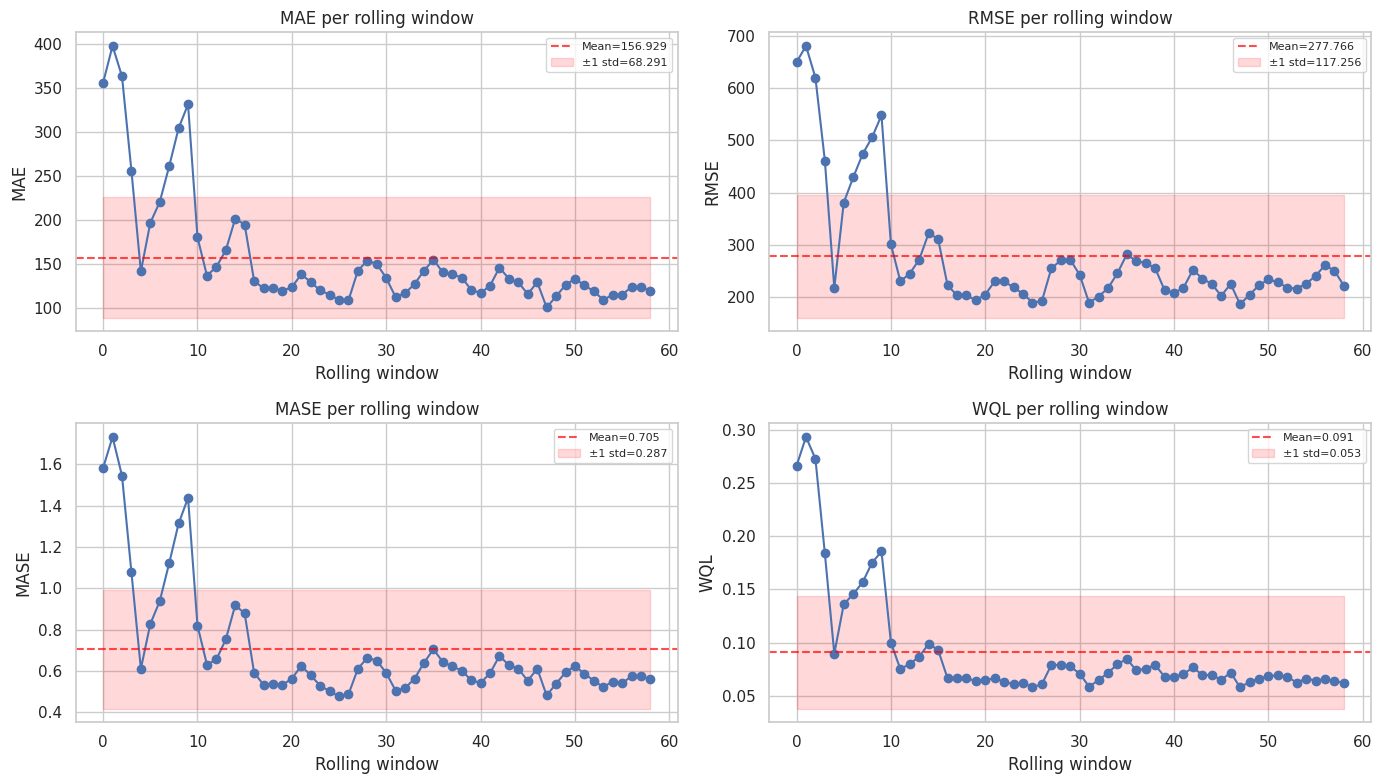

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, metric in zip(axes.flat, metric_cols):
    ax.plot(window_metrics_df['window'], window_metrics_df[metric], marker='o', linewidth=1.5)
    mean_val = window_metrics_df[metric].mean()
    std_val = window_metrics_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--', alpha=0.7,
               label=f'Mean={mean_val:.3f}')
    ax.fill_between(window_metrics_df['window'],
                     mean_val - std_val, mean_val + std_val,
                     alpha=0.15, color='red', label=f'±1 std={std_val:.3f}')
    ax.set_xlabel('Rolling window')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} per rolling window')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 9.2 Forecast vs actual — sensores representativos (última ventana)

Se seleccionan sensores de tráfico alto, medio y bajo para inspección visual, usando la última ventana rolling.

Active sensors (median > 10): 328
  Sensor 6716: recent median = 280 veh/h
  Sensor 6879: recent median = 1002 veh/h
  Sensor 6680: recent median = 2494 veh/h


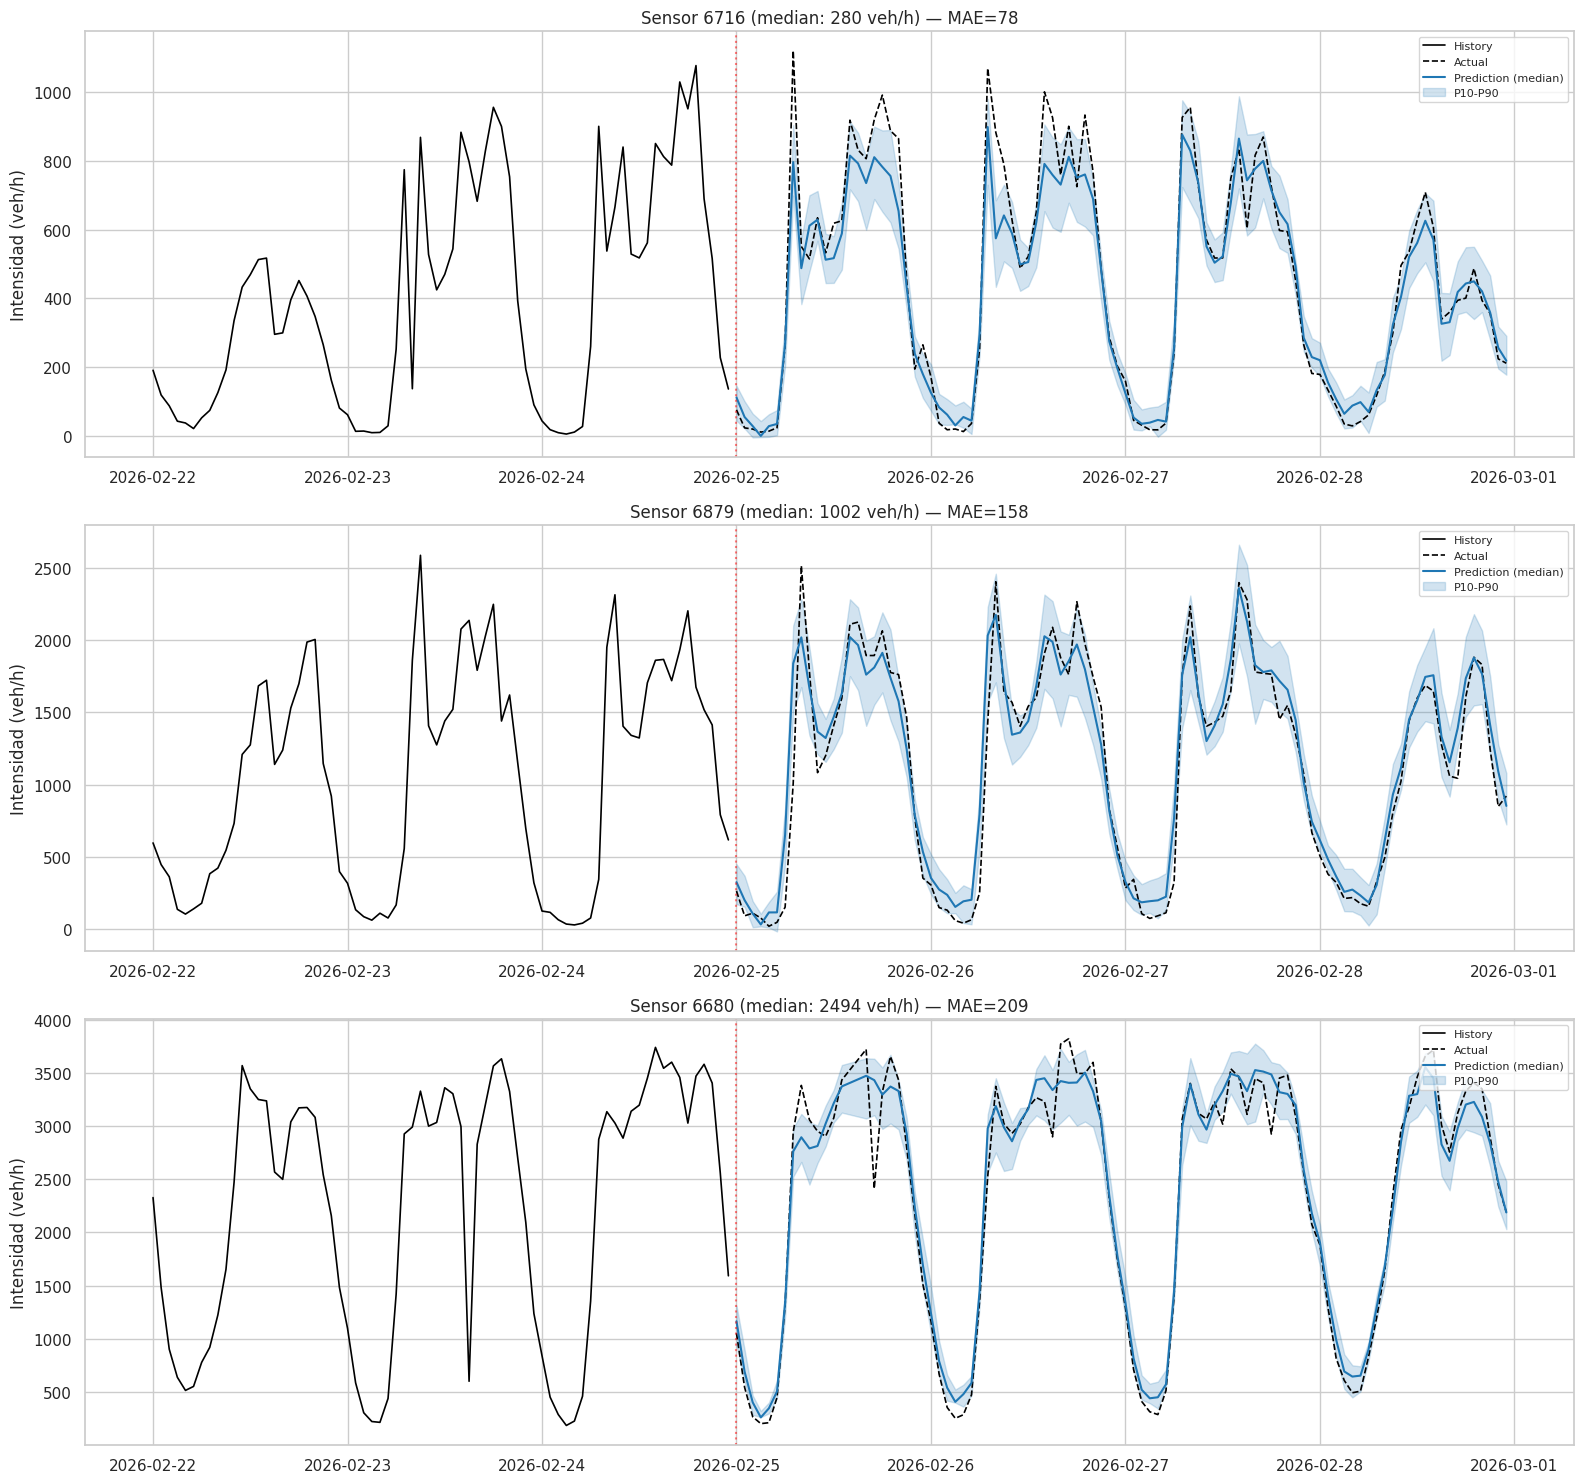

In [13]:
# Last window evaluation data
last_w = n_windows - 1
last_window_eval = all_eval_valid[all_eval_valid['window'] == last_w]

# Build history context for the last window
last_pred_start = test_start_idx + last_w * ROLLING_STEP
last_hist_start = last_pred_start - CONTEXT_LENGTH
df_last_history = df[(df['time_idx'] >= last_hist_start) & (df['time_idx'] < last_pred_start)]

# Select representative sensors using recent train median
recent_cutoff_idx = validation_cutoff - 30 * 24
recent_stats = (
    df_train[df_train['time_idx'] >= recent_cutoff_idx]
    .groupby(ID_COL)[TARGET]
    .median()
    .sort_values()
)
recent_stats = recent_stats[recent_stats > 10]
n_active = len(recent_stats)

sample_sensors = [
    recent_stats.index[n_active // 10],
    recent_stats.index[n_active // 2],
    recent_stats.index[9 * n_active // 10],
]

print(f'Active sensors (median > 10): {n_active}')
for s in sample_sensors:
    print(f'  Sensor {s}: recent median = {recent_stats[s]:.0f} veh/h')

CONTEXT_HOURS = 72

fig, axes = plt.subplots(len(sample_sensors), 1, figsize=(16, 5 * len(sample_sensors)), sharex=False)

for ax, sensor_id in zip(axes, sample_sensors):
    hist = df_last_history[df_last_history[ID_COL] == sensor_id].tail(CONTEXT_HOURS)
    actual = last_window_eval[last_window_eval[ID_COL] == sensor_id].sort_values(TS_COL)

    ax.plot(hist[TS_COL], hist[TARGET], color='black', linewidth=1.2, label='History')
    ax.plot(actual[TS_COL], actual[TARGET], color='black', linewidth=1.2, linestyle='--', label='Actual')
    ax.plot(actual[TS_COL], actual['predictions'], color='#1f77b4', linewidth=1.5, label='Prediction (median)')
    if 'q0.1' in actual.columns:
        ax.fill_between(actual[TS_COL], actual['q0.1'], actual['q0.9'], alpha=0.2, color='#1f77b4', label='P10-P90')

    sensor_mae = sensor_metrics[sensor_metrics[ID_COL] == sensor_id]['MAE'].values
    mae_str = f'MAE={sensor_mae[0]:.0f}' if len(sensor_mae) > 0 else ''
    ax.set_title(f'Sensor {sensor_id} (median: {recent_stats[sensor_id]:.0f} veh/h) — {mae_str}')
    ax.set_ylabel('Intensidad (veh/h)')
    ax.legend(loc='upper right', fontsize=8)
    ax.axvline(actual[TS_COL].min(), color='red', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### 9.3 Distribución de errores por sensor y error temporal

Se muestran las distribuciones de MAE y MASE por sensor (agregadas sobre todas las ventanas rolling), y el error por hora del día y día de la semana.

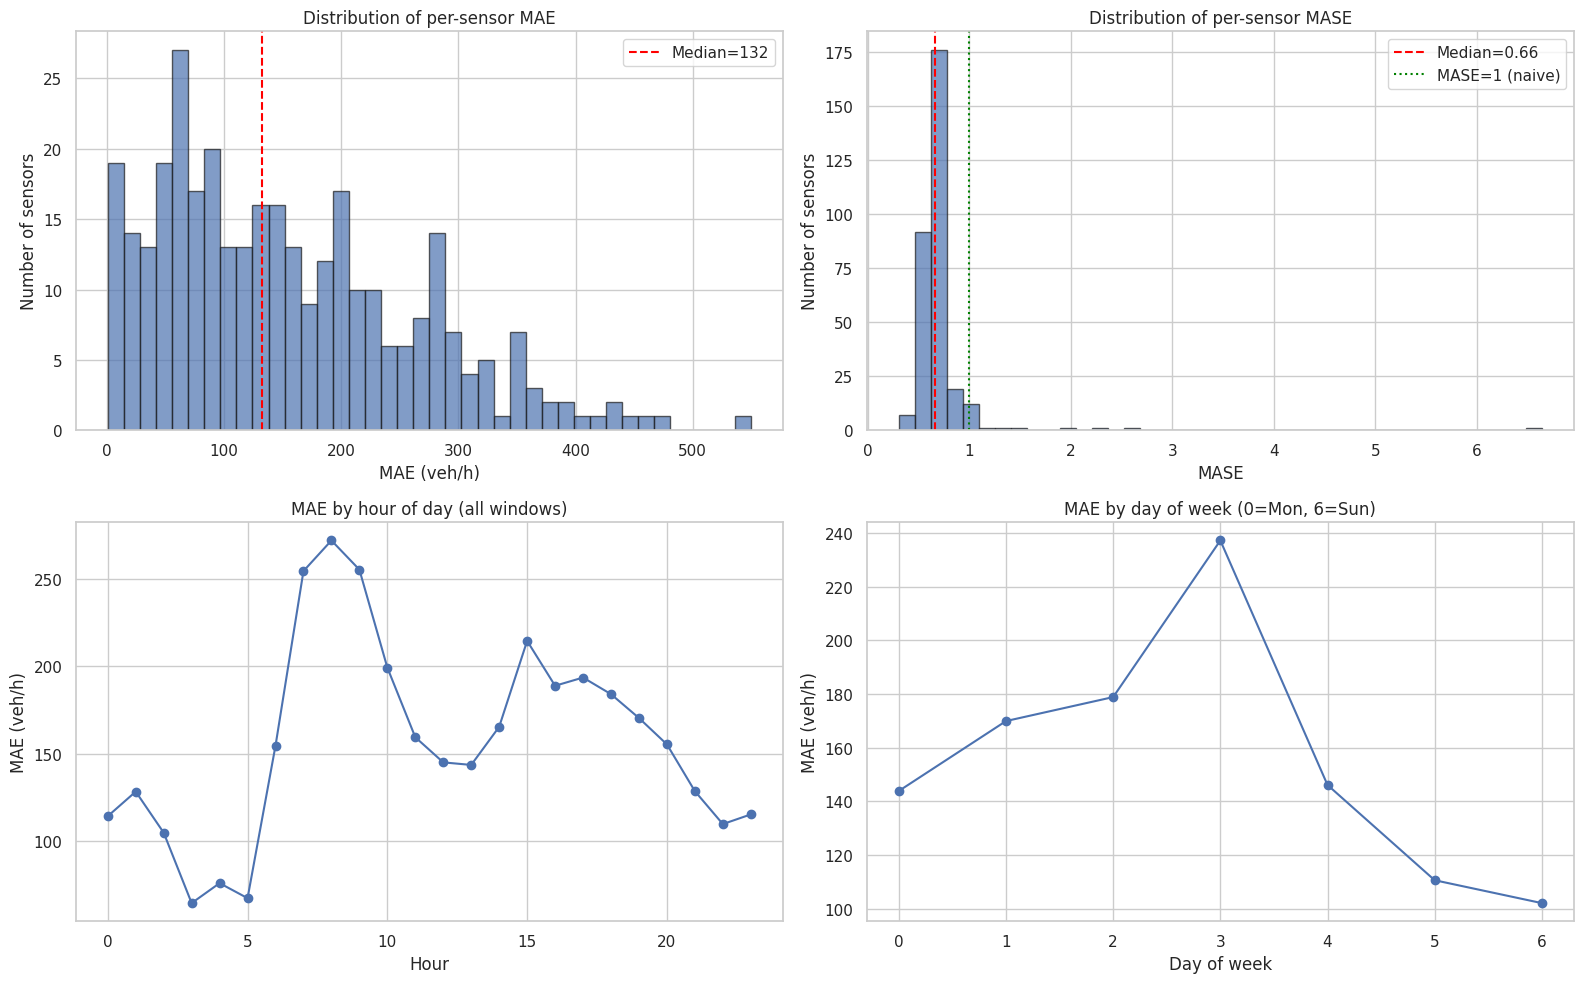

Sensors with MASE < 1 (beats naive): 96.2%


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# MAE distribution across sensors
axes[0, 0].hist(sensor_metrics['MAE'], bins=40, edgecolor='k', alpha=0.7)
axes[0, 0].axvline(sensor_metrics['MAE'].median(), color='red', linestyle='--',
                    label=f'Median={sensor_metrics["MAE"].median():.0f}')
axes[0, 0].set_xlabel('MAE (veh/h)')
axes[0, 0].set_ylabel('Number of sensors')
axes[0, 0].set_title('Distribution of per-sensor MAE')
axes[0, 0].legend()

# MASE distribution across sensors
valid_mase = sensor_metrics['MASE'].dropna()
axes[0, 1].hist(valid_mase, bins=40, edgecolor='k', alpha=0.7)
axes[0, 1].axvline(valid_mase.median(), color='red', linestyle='--',
                    label=f'Median={valid_mase.median():.2f}')
axes[0, 1].axvline(1.0, color='green', linestyle=':', label='MASE=1 (naive)')
axes[0, 1].set_xlabel('MASE')
axes[0, 1].set_ylabel('Number of sensors')
axes[0, 1].set_title('Distribution of per-sensor MASE')
axes[0, 1].legend()

# MAE by hour of day (aggregated over all windows)
all_eval_valid_tmp = all_eval_valid.copy()
all_eval_valid_tmp['hora_dia'] = all_eval_valid_tmp[TS_COL].dt.hour
all_eval_valid_tmp['dia_semana'] = all_eval_valid_tmp[TS_COL].dt.dayofweek
all_eval_valid_tmp['abs_error'] = np.abs(all_eval_valid_tmp[TARGET] - all_eval_valid_tmp['predictions'])

all_eval_valid_tmp.groupby('hora_dia')['abs_error'].mean().plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('MAE by hour of day (all windows)')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('MAE (veh/h)')

# MAE by day of week
all_eval_valid_tmp.groupby('dia_semana')['abs_error'].mean().plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('MAE by day of week (0=Mon, 6=Sun)')
axes[1, 1].set_xlabel('Day of week')
axes[1, 1].set_ylabel('MAE (veh/h)')

plt.tight_layout()
plt.show()

pct_beats_naive = (valid_mase < 1.0).mean() * 100
print(f'Sensors with MASE < 1 (beats naive): {pct_beats_naive:.1f}%')

### 9.4 Error por horizonte de predicción

Además de las métricas globales agregadas sobre todas las ventanas rolling, resulta útil estudiar cómo cambia el error en función del **horizonte de predicción** dentro de cada forecast de 96 horas.

Aquí se calcula el **MAE** y el **MASE** para cada paso horario \(h = 1, \dots, 96\), resumiendo cada horizonte mediante su **media** y **desviación estándar** a lo largo de todas las ventanas rolling.

In [15]:
# ============================================================
# Horizon-wise MAE / MASE for TimeXer
# ============================================================

horizon_eval = all_eval_valid.copy()

# Map each rolling window to its forecast start timestamp
window_start_map = window_metrics_df.set_index("window")["window_start"]
horizon_eval["window_start"] = pd.to_datetime(horizon_eval["window"].map(window_start_map))

# Horizon step within each rolling window: 1..PREDICTION_LENGTH
horizon_eval["horizon"] = (
                                  (horizon_eval[TS_COL] - horizon_eval["window_start"]).dt.total_seconds() // 3600
                          ).astype(int) + 1

# Keep only valid forecast horizons
horizon_eval = horizon_eval[
    horizon_eval["horizon"].between(1, PREDICTION_LENGTH)
].copy()

# Absolute error
horizon_eval["abs_error"] = np.abs(horizon_eval[TARGET] - horizon_eval["predictions"])

# Per-row scaled error for MASE
horizon_eval["mase_denom"] = horizon_eval[ID_COL].map(mase_denominators)
valid_mase = horizon_eval["mase_denom"].notna() & (horizon_eval["mase_denom"] > 0)

horizon_eval["scaled_abs_error"] = np.nan
horizon_eval.loc[valid_mase, "scaled_abs_error"] = (
        horizon_eval.loc[valid_mase, "abs_error"] / horizon_eval.loc[valid_mase, "mase_denom"]
)

# Per-window, per-horizon metrics
horizon_window_metrics = (
    horizon_eval.groupby(["window", "horizon"])
    .apply(
        lambda g: pd.Series({
            "MAE": g["abs_error"].mean(),
            "MASE": g["scaled_abs_error"].mean(),
            "n_rows": len(g),
        }),
        include_groups=False
    )
    .reset_index()
)

# Summary across windows for each horizon
horizon_summary = horizon_window_metrics.groupby("horizon").agg(
    MAE_mean=("MAE", "mean"),
    MAE_std=("MAE", "std"),
    MASE_mean=("MASE", "mean"),
    MASE_std=("MASE", "std"),
).reset_index()

display(horizon_summary.round(4))

,horizon,MAE_mean,MAE_std,MASE_mean,MASE_std
0,1,104.0607,44.3054,0.4652,0.1707
1,2,124.7397,163.5701,0.5437,0.6785
2,3,94.8597,135.9695,0.4119,0.5696
3,4,53.8162,64.8273,0.2464,0.2715
4,5,67.3891,30.0205,0.2960,0.1251
...,...,...,...,...,...
91,92,177.0247,64.3961,0.8301,0.2727
92,93,163.2476,66.1717,0.7482,0.2769
93,94,128.2305,75.2927,0.5775,0.2975
94,95,106.5452,57.3740,0.4733,0.2233


La siguiente figura muestra la **media ± 1 desviación estándar** del MAE y el MASE para cada
horizonte horario, calculada sobre las 59 ventanas rolling.

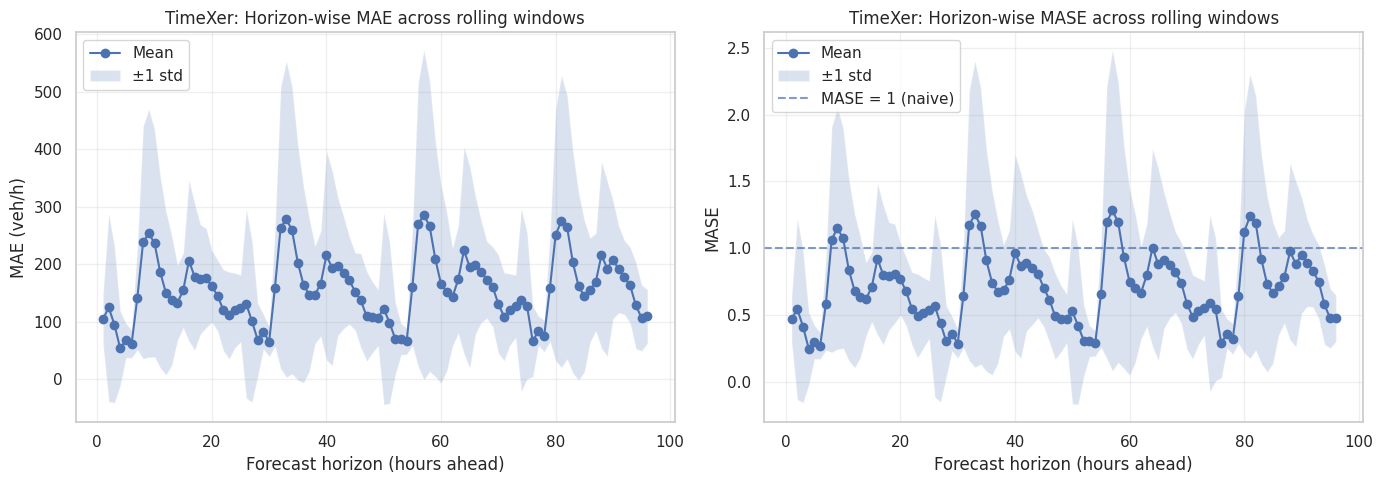

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE with ±1 std band
axes[0].plot(horizon_summary["horizon"], horizon_summary["MAE_mean"], marker="o", label="Mean")
axes[0].fill_between(
    horizon_summary["horizon"],
    horizon_summary["MAE_mean"] - horizon_summary["MAE_std"],
    horizon_summary["MAE_mean"] + horizon_summary["MAE_std"],
    alpha=0.2,
    label="±1 std"
)
axes[0].set_title("TimeXer: Horizon-wise MAE across rolling windows")
axes[0].set_xlabel("Forecast horizon (hours ahead)")
axes[0].set_ylabel("MAE (veh/h)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# MASE with ±1 std band
axes[1].plot(horizon_summary["horizon"], horizon_summary["MASE_mean"], marker="o", label="Mean")
axes[1].fill_between(
    horizon_summary["horizon"],
    horizon_summary["MASE_mean"] - horizon_summary["MASE_std"],
    horizon_summary["MASE_mean"] + horizon_summary["MASE_std"],
    alpha=0.2,
    label="±1 std"
)
axes[1].axhline(1.0, linestyle="--", alpha=0.7, label="MASE = 1 (naive)")
axes[1].set_title("TimeXer: Horizon-wise MASE across rolling windows")
axes[1].set_xlabel("Forecast horizon (hours ahead)")
axes[1].set_ylabel("MASE")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

### 9.5 Training loss curve

Available scalar tags: ['hp_metric', 'lr-Adam', 'train_loss_step', 'epoch', 'train_loss_epoch', 'train_MAE', 'val_MAE', 'val_MAE_pooled']
Selected train loss tag: train_loss_step
Selected val loss tag  : None
Selected train MAE tag : train_MAE
Selected val MAE tag   : val_MAE


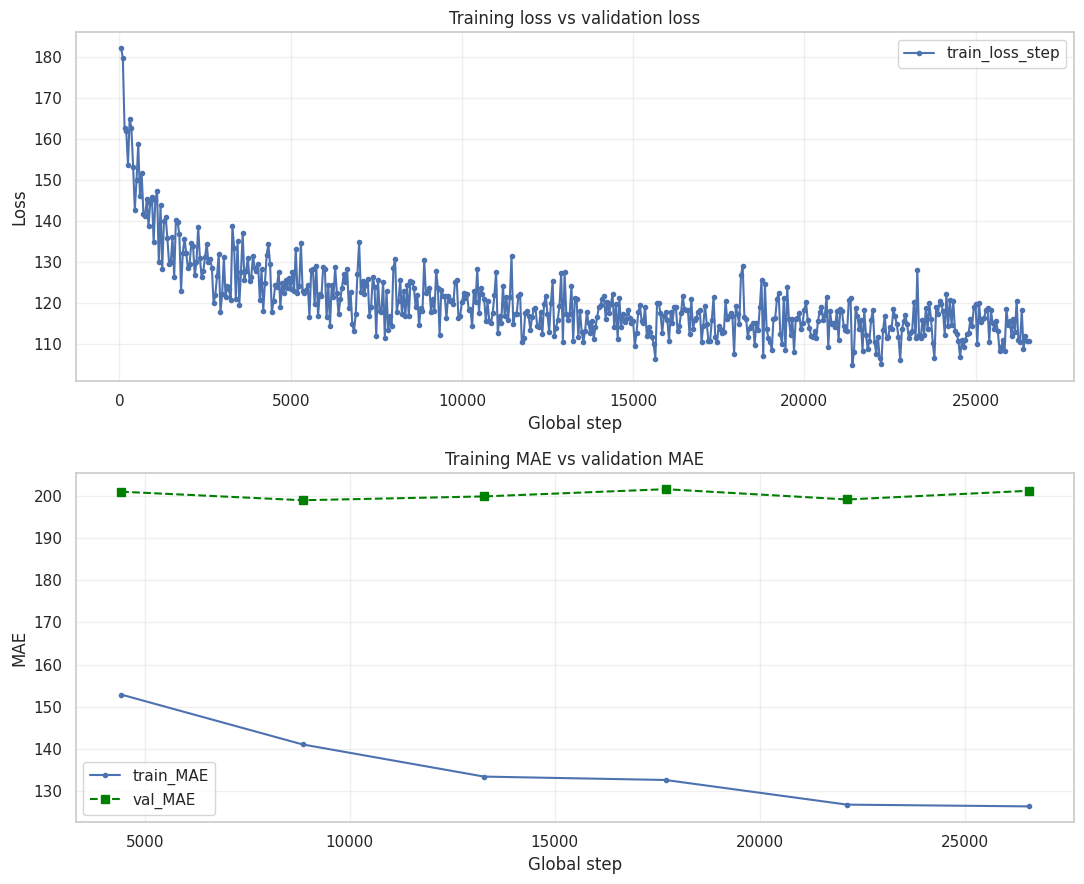

In [17]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import matplotlib.pyplot as plt

ea = event_accumulator.EventAccumulator(trainer.logger.log_dir)
ea.Reload()

scalar_tags = ea.Tags().get("scalars", [])
print("Available scalar tags:", scalar_tags)

def read_scalar(tag):
    events = ea.Scalars(tag)
    return pd.DataFrame({
        "step": [e.step for e in events],
        "value": [e.value for e in events],
    })

def first_existing(candidates, available):
    for candidate in candidates:
        if candidate in available:
            return candidate
    return None

# Detect tags robustly
train_loss_tag = first_existing(
    ["train_loss_step", "train_loss", "train_loss_epoch"],
    scalar_tags
)

val_loss_tag = first_existing(
    ["val_loss"],
    scalar_tags
)

train_mae_tag = first_existing(
    ["train_MAE", "MAE/train"],
    scalar_tags
)

val_mae_tag = first_existing(
    ["val_MAE", "MAE/val", "MAE"],
    scalar_tags
)

print(f"Selected train loss tag: {train_loss_tag}")
print(f"Selected val loss tag  : {val_loss_tag}")
print(f"Selected train MAE tag : {train_mae_tag}")
print(f"Selected val MAE tag   : {val_mae_tag}")

if not any([train_loss_tag, val_loss_tag, train_mae_tag, val_mae_tag]):
    raise ValueError(f"No matching scalar tags found. Available scalar tags: {scalar_tags}")

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=False)

# -------------------------
# Plot 1: Loss
# -------------------------
ax1 = axes[0]
loss_lines = []
loss_labels = []

if train_loss_tag:
    train_loss_df = read_scalar(train_loss_tag)
    l1, = ax1.plot(
        train_loss_df["step"],
        train_loss_df["value"],
        marker=".",
        label=train_loss_tag
    )
    loss_lines.append(l1)
    loss_labels.append(train_loss_tag)

if val_loss_tag:
    val_loss_df = read_scalar(val_loss_tag)
    l2, = ax1.plot(
        val_loss_df["step"],
        val_loss_df["value"],
        marker="o",
        label=val_loss_tag
    )
    loss_lines.append(l2)
    loss_labels.append(val_loss_tag)

ax1.set_title("Training loss vs validation loss")
ax1.set_xlabel("Global step")
ax1.set_ylabel("Loss")
if loss_lines:
    ax1.legend(loss_lines, loss_labels, loc="best")
ax1.grid(True, alpha=0.3)

# -------------------------
# Plot 2: MAE
# -------------------------
ax2 = axes[1]
mae_lines = []
mae_labels = []

if train_mae_tag:
    train_mae_df = read_scalar(train_mae_tag)
    l3, = ax2.plot(
        train_mae_df["step"],
        train_mae_df["value"],
        marker=".",
        label=train_mae_tag
    )
    mae_lines.append(l3)
    mae_labels.append(train_mae_tag)

if val_mae_tag:
    val_mae_df = read_scalar(val_mae_tag)
    l4, = ax2.plot(
        val_mae_df["step"],
        val_mae_df["value"],
        linestyle="--",
        marker="s",
        color="green",
        label=val_mae_tag
    )
    mae_lines.append(l4)
    mae_labels.append(val_mae_tag)

ax2.set_title("Training MAE vs validation MAE")
ax2.set_xlabel("Global step")
ax2.set_ylabel("MAE")
if mae_lines:
    ax2.legend(mae_lines, mae_labels, loc="best")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.6 Rendimiento agregado por bloques de horizonte

Para facilitar la interpretación del forecast de 96 horas, se agrupan los pasos horarios en cuatro bloques de 24 horas:

- **1–24h**
- **25–48h**
- **49–72h**
- **73–96h**

Esta agregación permite resumir el comportamiento del modelo por **día de anticipación**, reduciendo el ruido de las curvas paso a paso. Así, puede evaluarse de forma más clara si el modelo presenta una degradación progresiva al avanzar desde el primer hasta el cuarto día, o si el rendimiento se mantiene relativamente estable y las diferencias observadas se deben principalmente a patrones intradiarios específicos.

Este resumen es especialmente útil para la discusión final del caso TimeXer, ya que traduce el análisis por horizonte a una escala más interpretable para forecasting operativo multidiario.

In [18]:
horizon_eval["horizon_block"] = pd.cut(
    horizon_eval["horizon"],
    bins=[0, 24, 48, 72, 96],
    labels=["1-24h", "25-48h", "49-72h", "73-96h"]
)

block_metrics = horizon_eval.groupby("horizon_block").agg(
    MAE=("abs_error", "mean"),
    MASE=("scaled_abs_error", "mean"),
    n_rows=("abs_error", "size"),
).reset_index()

print("=== Metrics by horizon block ===")
display(block_metrics.round(4))

=== Metrics by horizon block ===


,horizon_block,MAE,MASE,n_rows
0,1-24h,146.4378,0.6615,446776
1,25-48h,158.7732,0.7142,446811
2,49-72h,160.0584,0.7200,446770
3,73-96h,161.2759,0.7261,446689


## 10. Conclusiones

### 10.1 Resumen del enfoque

Se ha implementado el modelo **TimeXer** — variante **ALL_FORE** (pytorch-forecasting 1.6.1, ~16.1 M parámetros) para
forecasting de la intensidad de tráfico en los sensores de la M30 de Madrid, con un horizonte de
predicción de **96 horas** (4 días) y un contexto de **1440 horas** (60 días).

Variante **ALL_FORE**: sin covariables de clima observado (`temp`/`prcp`) — solo `forecast_temp`/`forecast_prec` en encoder y decoder, alineada con Chronos-2 ALL_FORE.

La evaluación emplea **59 rolling windows** sobre el conjunto de test (último 14.5% = 1,488 h
por sensor), con paso de 24 h, garantizando comparabilidad directa con los experimentos Chronos-2.

### 10.2 Diferencias clave con Chronos-2

| Aspecto              | Chronos-2                      | TimeXer                              |
|----------------------|--------------------------------|--------------------------------------|
| Tipo                 | Fundacional (preentrenado)     | Supervisado (entrenado en-dominio)   |
| Inferencia           | Zero-shot                      | Requiere entrenamiento               |
| Covariables          | Inferencia automática          | Declaración explícita en dataset     |
| Patches              | Internos al modelo             | Configurable (`patch_length=24`)     |
| Salida               | Cuantiles nativos              | QuantileLoss configurable            |
| Hardware             | Solo inferencia                | Entrenamiento + inferencia           |
| Evaluación           | Rolling window                 | Rolling window (idéntico split)      |

### 10.3 Entrenamiento y tiempo de cómputo

El entrenamiento completó en **6 épocas** (early stopping con `PATIENCE=4`, monitorizando `val_MAE`).
El mejor checkpoint se obtuvo en la **época 2** con `val_MAE=198.97`. El tiempo total de entrenamiento
fue de **3 h 24 min 55 s** sobre GPU (CUDA).
La inferencia rolling sobre las 59 ventanas de test tomó **4 min 47 s** (~4.9 s/ventana).

### 10.4 Resultados globales

Métricas agregadas sobre las **59 ventanas rolling** (media ± desviación estándar):

| Métrica | Media   | Std     | Mín    | Máx    |
|---------|---------|---------|--------|--------|
| MAE     | 156.9   | 68.3    | 100.2  | 397.3  |
| RMSE    | 277.8   | 117.3   | 186.0  | 680.6  |
| MASE    | 0.705   | 0.287   | 0.478  | 1.732  |
| WQL     | 0.0912  | 0.0529  | 0.0583 | 0.2931 |

El MASE < 1 en el **88.1% de las ventanas** (52 de 59) confirma que TimeXer supera al pronóstico naïve
estacional en la gran mayoría de los casos.

### 10.5 Distribución por sensor

Sobre los **331 sensores** con denominadores MASE válidos (de 351 disponibles):
- **MAE mediano** por sensor: 132.2 veh/h
- **MASE mediano** por sensor: 0.662
- Alta dispersión: el 25% de los sensores con peor MAE supera los 220.8 veh/h,
  mientras que el 25% mejor se mantiene por debajo de 64.6 veh/h.

### 10.6 Estabilidad temporal — ventanas rolling

Se observan **dos clusters de degradación** claros:

1. **W0–W2** (29 dic 2025 – 3 ene 2026, Navidad/Año Nuevo): MASE entre 1.544 y 1.732.
   El modelo no generaliza bien a la caída del tráfico festivo navideño.
2. **W7–W9** (5–10 ene 2026, Reyes Magos y vuelta): MASE entre 1.121 y 1.437.
   La ventana W1 (MASE=1.732) es la peor del experimento, coincidiendo con la semana de
   Año Nuevo (inicio 30 dic 2025) como inicio del horizonte.

El **mejor período** corresponde a las ventanas W24–W26 (22–27 ene), con MASE inferior a 0.49.
La ventana W25 (23–26 ene, MAE=108.7, MASE=0.478) es la de mejor rendimiento en MASE;
la ventana W47 (14–17 feb, MAE=100.2, MASE=0.482) es la de mejor rendimiento en MAE.

### 10.7 Error por horizonte de predicción

El análisis por horizonte muestra un patrón **no monótono con ciclos de 24 horas**, coherente con
los lags aprendidos `[1h, 24h, 48h, 96h]`: los horizontes múltiplo de 24h tienden a presentar
errores más bajos que sus vecinos inmediatos, ya que el modelo puede apoyarse en el lag
correspondiente. Se observa un MASE elevado hacia las últimas décadas del horizonte
(h=92: MASE=0.830) con descensos abruptos en los puntos ancla (h=95: MASE=0.473, h=96: MASE=0.475).

### 10.8 Rendimiento agregado por bloques de horizonte

Agrupando los 96 pasos horarios en bloques de 24 h (un día de anticipación):

| Bloque  | MAE (veh/h) | MASE  |
|---------|-------------|-------|
| 1–24h   | 146.4       | 0.661 |
| 25–48h  | 158.8       | 0.714 |
| 49–72h  | 160.1       | 0.720 |
| 73–96h  | 161.3       | 0.726 |

El error aumenta **de forma gradual pero contenida** al alejarse del instante de predicción:
el MAE crece un +10.1% del primer al cuarto día (146.4 → 161.3 veh/h), y el MASE un +9.8%
(0.661 → 0.726). La degradación es monótona y moderada, sin colapso en el cuarto día, lo que
indica que el modelo mantiene utilidad práctica durante las 96 horas completas del horizonte.

### 10.9 Comparación con Chronos-2 (HH168, mismo split)

| Métrica | Chronos-2 HH168   | TimeXer HH1440    | Δ (TimeXer − Chronos) |
|---------|-------------------|-------------------|-----------------------|
| MAE     | 142.2 ± 62.9      | 156.9 ± 68.3      | +14.7 (+10.3%)        |
| RMSE    | 263.7 ± 108.8     | 277.8 ± 117.3     | +14.1 (+5.3%)         |
| MASE    | 0.622 ± 0.257     | 0.705 ± 0.287     | +0.083 (+13.3%)       |
| WQL     | 0.0805 ± 0.0387   | 0.0912 ± 0.0529   | +0.0107 (+13.3%)      |

**Chronos-2 supera a TimeXer en todas las métricas** con este contexto de 1440h.
Este resultado es notable: el modelo fundacional zero-shot proporciona mejores predicciones
que el transformer supervisado entrenado en-dominio. Con 1440h de contexto, TimeXer no logra
superar la transferencia de conocimiento aportada por el preentrenamiento de Chronos-2.

### 10.10 Perspectivas

El rendimiento de TimeXer podría mejorar con:
- **Búsqueda de hiperparámetros**: el mejor checkpoint fue época 2 (de 6), sugiriendo que
  el modelo puede necesitar ajuste de lr, `hidden_size` o `PATIENCE`.
- **Ajuste del `patch_length`**: 7 patches de 24h puede ser demasiado grueso para capturar
  patrones intra-diarios finos.
- **Contexto más corto y selectivo**: con 1440h de contexto el modelo ya tiene 60 días de historia;
  explorar si un contexto más reducido (p.ej. 168h) mejora la capacidad de generalización en
  periodos festivos.